Для человека полученные id просто номера. Для компьютера так же. Здесь кроется огромная проблема, которую нельзя игнорировать. Если мы подадим эти числа в нейросеть напрямую, модель начнет видеть математические связи там, где их нет. Число 4650 («смета») больше числа 101 («и»), но означает ли это, что слово «смета» значимее, «тяжелее» или «важнее»? Конечно, нет. В токенизации нет порядка, нет расстояния. ID 16348 («Кот») не обязательно ближе к ID 7805 («очень»), чем к ID 102 («на»).

Нам нужно превратить эти сухие индексы в что-то, с чем можно работать математически. Нам нужно пространство, где смысл слова выражается его положением. Именно этим занимается слой эмбеддингов. Это первый настоящий слой нашей будущей модели, который содержит обучаемые параметры.

## Эмбеддинги

Представьте себе огромную карту. На ней нет городов и рек, вместо них расположены слова. Но не хаотично, а по смыслу. В одном углу карты собраны все слова, связанные с животными: «кот», «пес», «хвост», «мяу». В другом — слова про еду: «сметана», «еда», «вкусно».

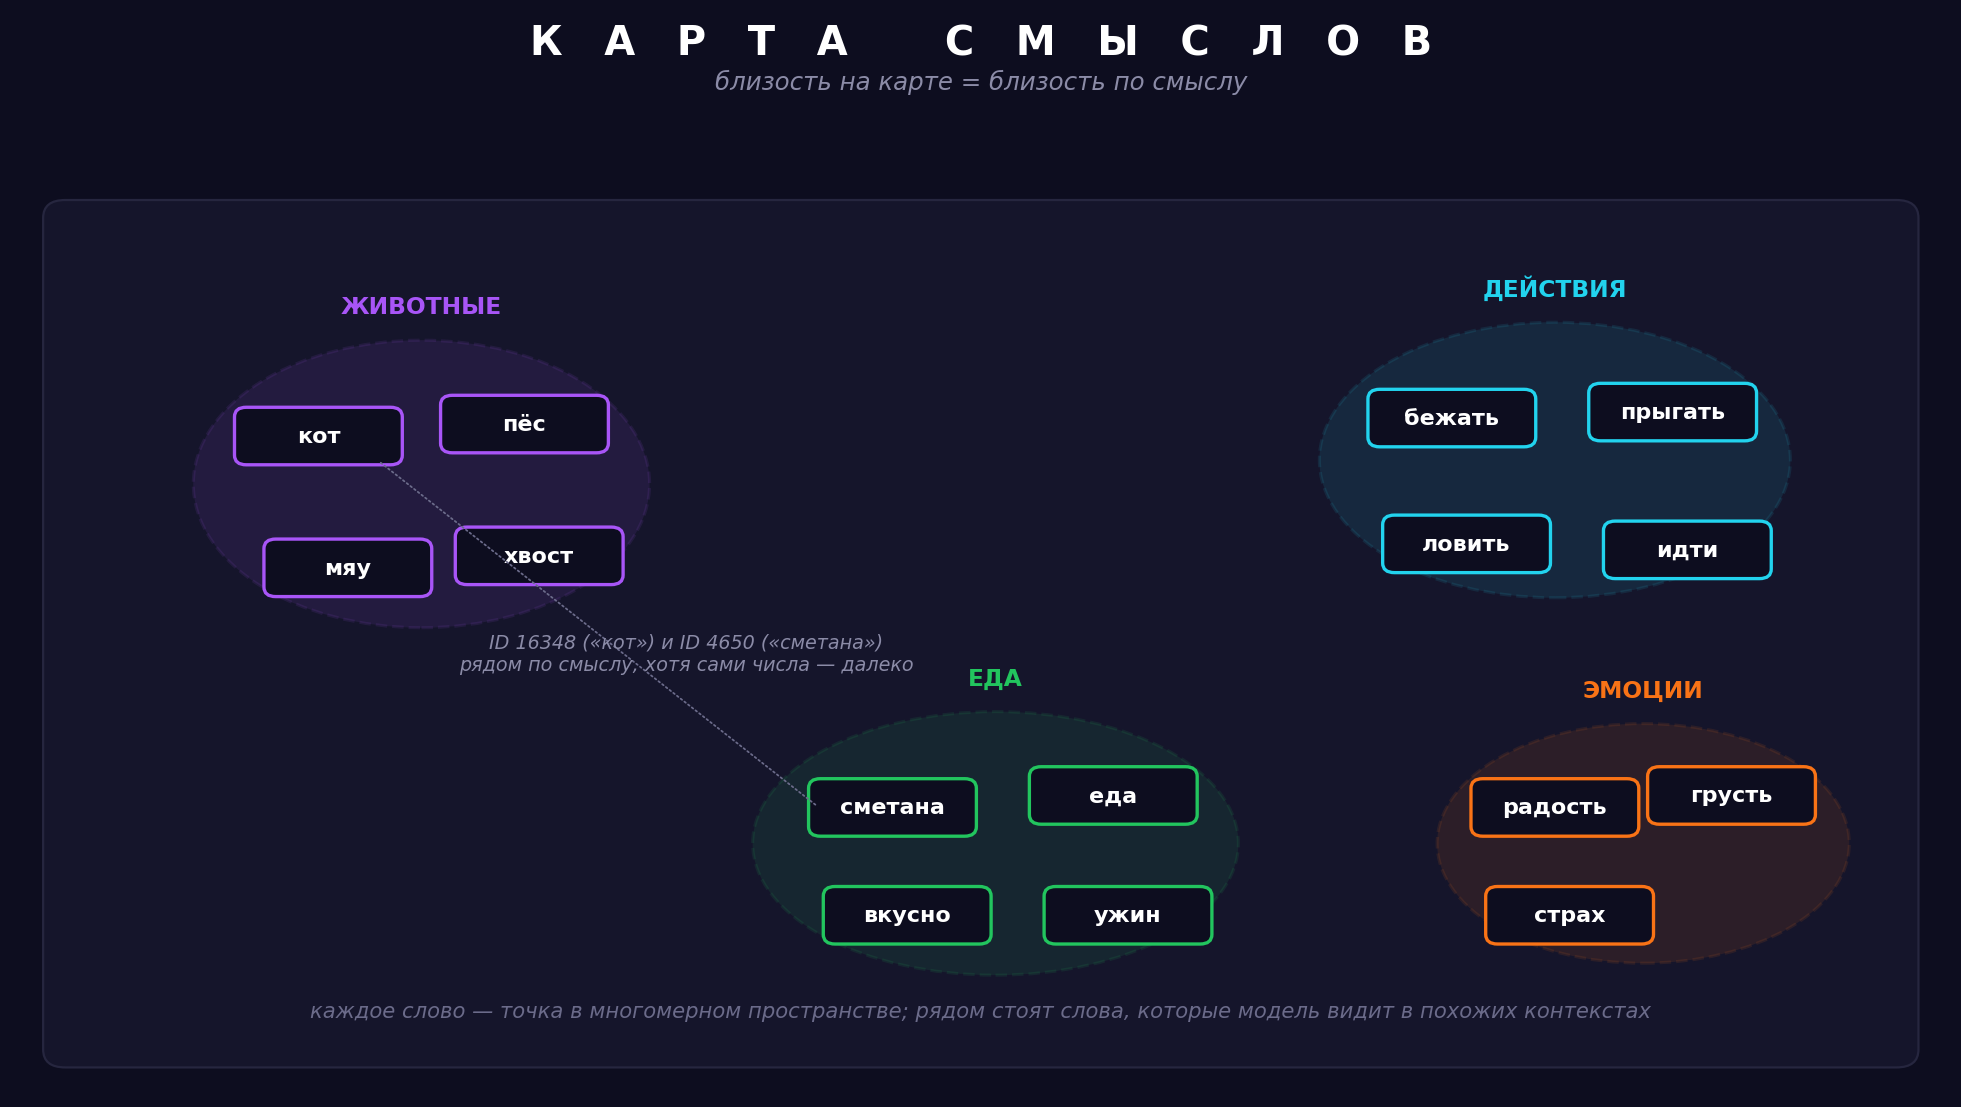

Расстояние между точками на этой карте имеет значение. Если векторы слов близки друг к другу, значит, и слова похожи по смыслу или употреблению. Если мы захотим найти синоним к слову «кот», нам достаточно посмотреть, какие векторы лежат рядом с ним в этом пространстве.

Слой эмбеддингов — это и есть инструмент, который создает такую карту. Он берет номер слова (ID) и выдает его координаты на этой карте. Вместо одного числа мы получаем вектор — список из десятков или сотен чисел.

В больших языковых моделях это определяется словом «параметры». 

Например в современных моделях таких как DeepSeek-V3.2  , можно посмотреть в файле config.json на Hugging Face

Размер такого вектор будет:

"hidden_size": 7168,

                  
То есть слово «кот» будем описано  вектором из 7168 чисел.

В итоге, после обучения, у нас будет вот такая карта:

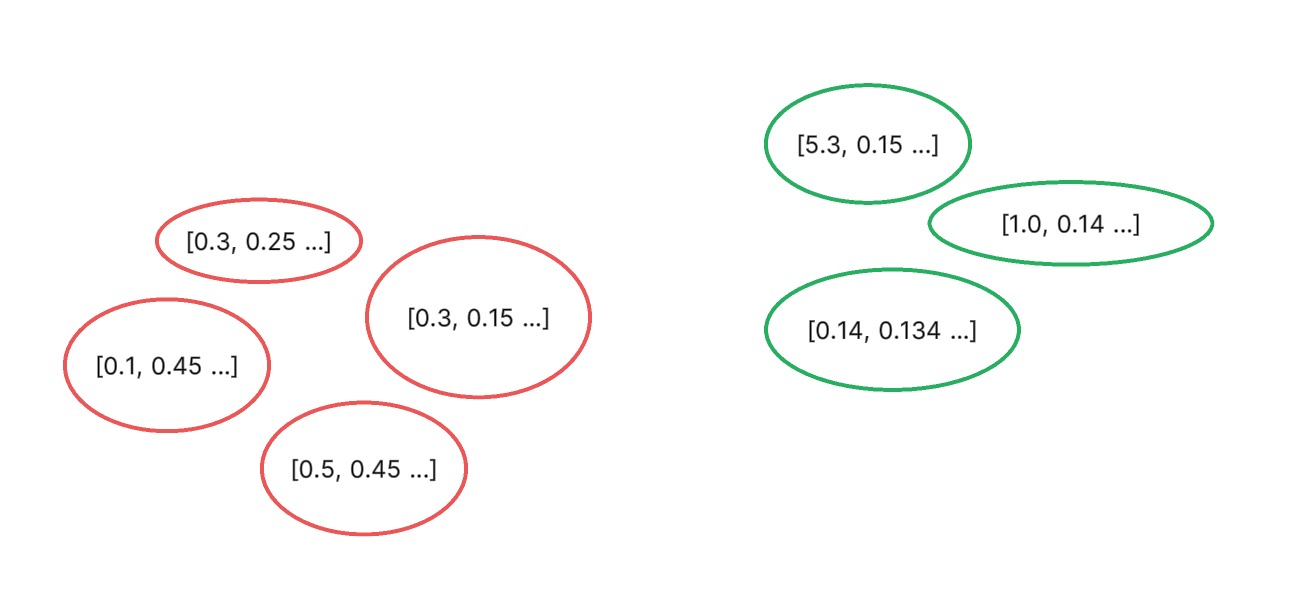


Где, у каждого слова будет свой вектор для описания.

Обратите внимание на закономерность: чем больше модель, тем больше размер эмбеддинга

huggingface.co

- Малые модели (до 100M параметров): 384–768
- Средние модели (100M–1B): 768–1024
- Большие модели (1B–10B): 2048–4096
- Огромные модели (10B+): 4096–8192+

Это не случайность. Размер эмбеддинга определяет, насколько «богатый» смысл может уместить модель в одном векторе. Если у вас всего 5 чисел на слово, вы не сможете закодировать все нюансы значения, контекста, стиля и грамматики.

**Важно понять разницу между токенизацией и эмбеддингом.**


- Токенизация — это перевод текста в идентификаторы. Это фиксированный процесс, словарь не меняется во время обучения, вы можете сами создать словарь, а можете использовать готовый.


- Эмбеддинг — это перевод идентификаторов в векторы. Это гибкий процесс. Изначально векторы заполнены случайными числами. Модель не знает, что «кот» — это животное. Но по мере обучения, когда она видит, что «кот» часто встречается рядом со словами «мяу» и «шерсть», она подкручивает значения в векторе «кота» так, чтобы они стали похожи на векторы соседей.

## От ID к Вектору: Token Embedding

Представьте себе огромный словарь. В нашем случае это таблица, где каждой строке соответствует ID токена, а в ячейках хранятся числа.

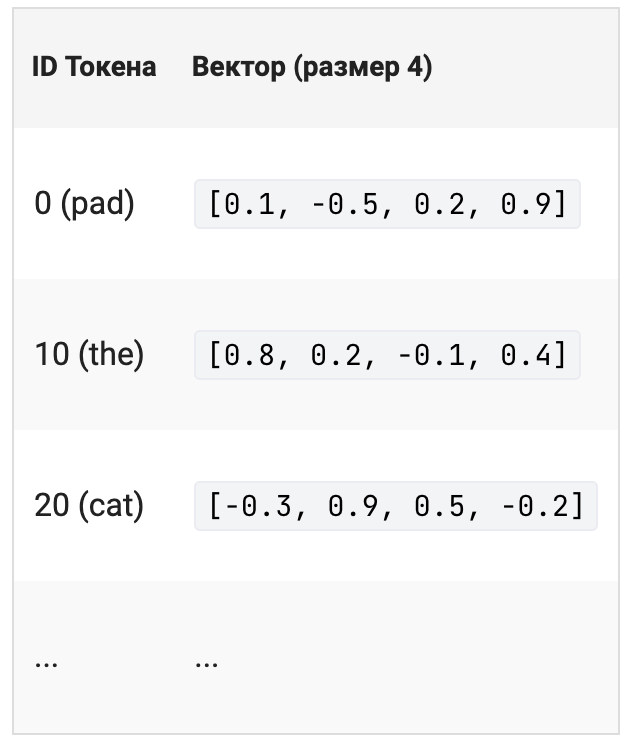

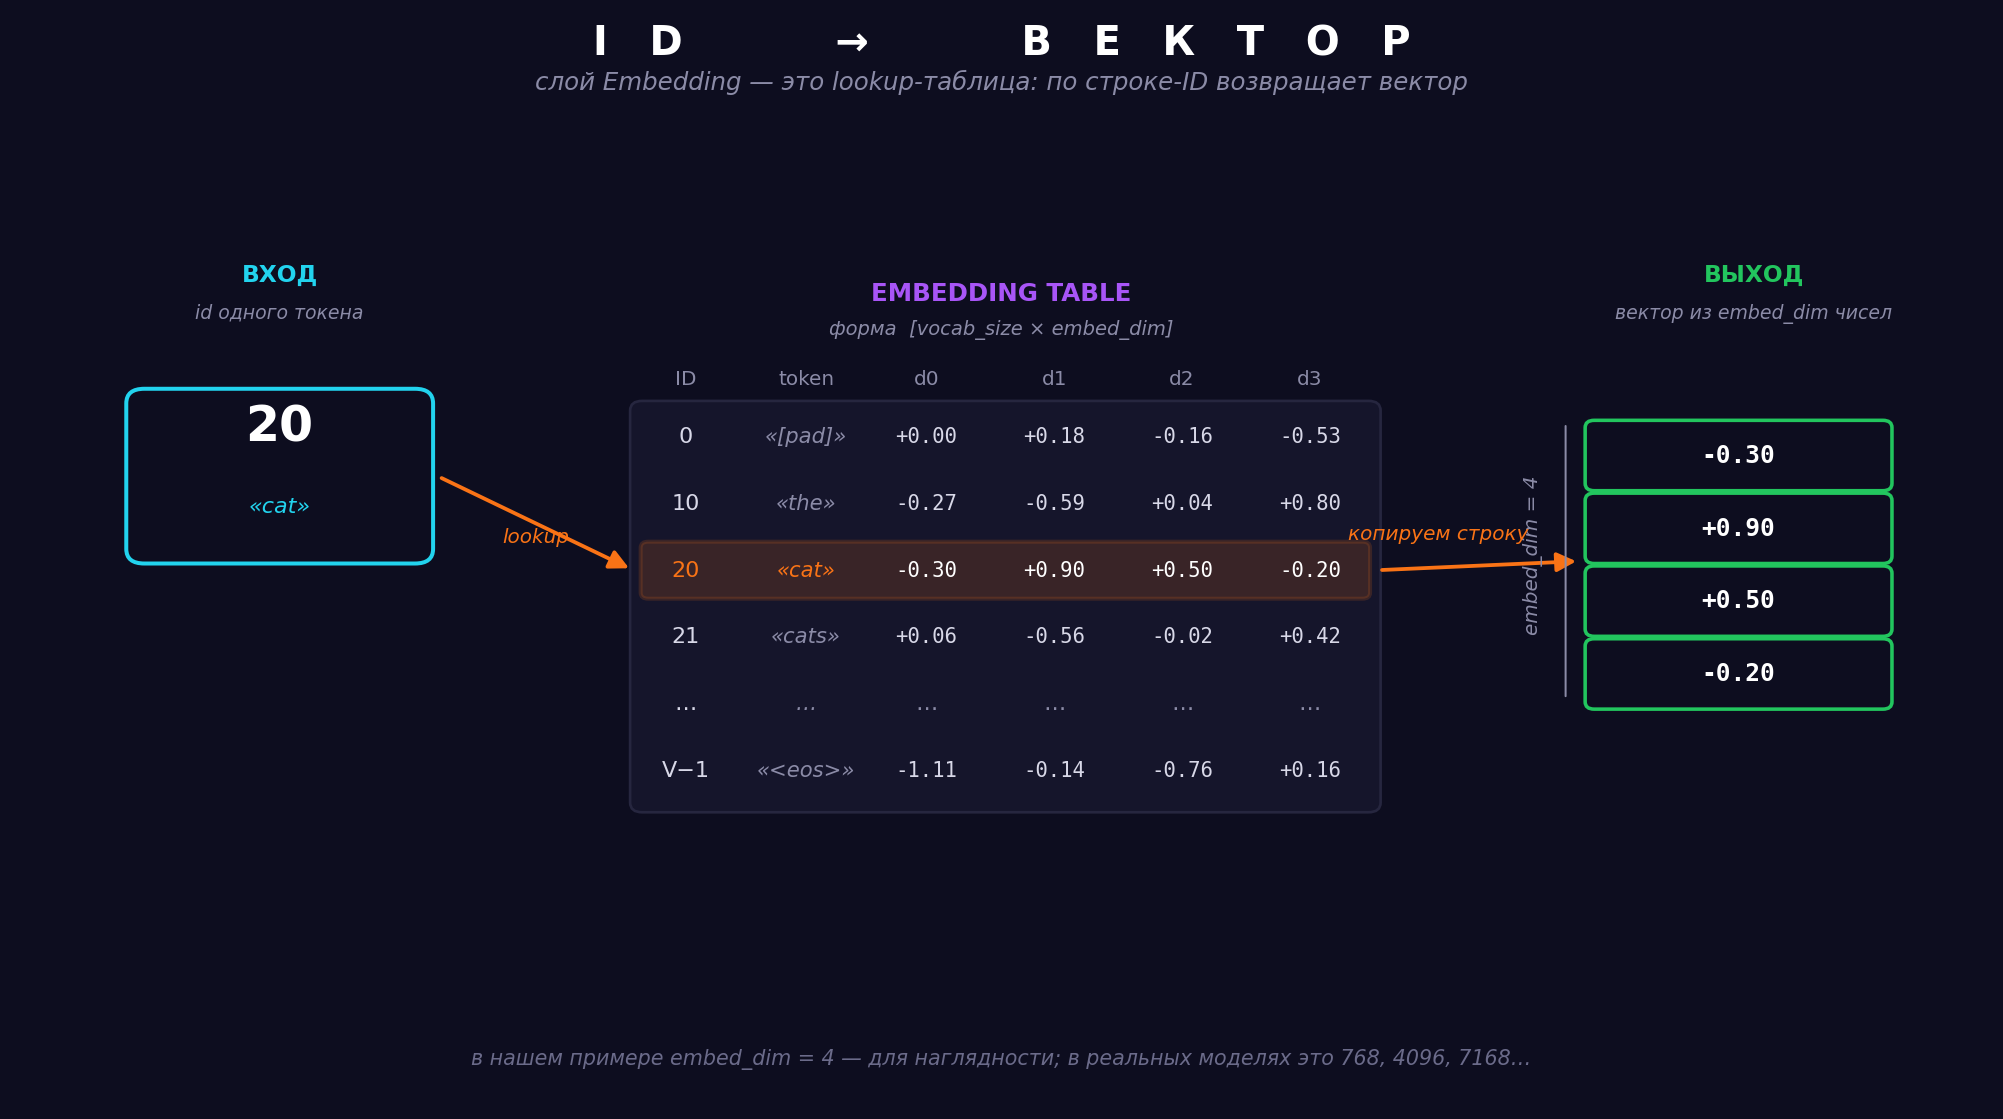

Эта таблица называется **Слой Встраивания (Embedding Layer)**. Она обучаемая. В начале обучения векторы заполняются случайными числами. Но в процессе обучения модель понимает: «Ага, векторы для слов "кот" и "кошка" должны быть похожи, потому что они встречаются в похожих контекстах».

Таким образом, вместо одного числа (ID) модель получает целый набор чисел (вектор), который несёт семантический смысл.

**Размерность вложения (Embedding Dimension)**

Сколько чисел должно быть в векторе? Это гиперпараметр, который мы назовём embed_dim.

- Если embed_dim = 4, вектор маленький, модель компактная и быстрая, но смысла в него почти не уместить.
- Если embed_dim = 768 (как в GPT-2 small), вектор большой, модель может хранить сложные связи, но требует больше памяти.

Для нашего курса мы выберем золотую середину для демонстрации: embed_dim = 16.

##  Зачем нужно Positional Encoding?

Архитектура Transformer (которую мы будем строить) обладает  свойством: она перестановочно инвариантна (permutation invariant).

Если вы передадите ей набор векторов слов: `[«Кот», «любит», «сметану»]`, она обработает их все одновременно (параллельно). Для неё нет понятия «первое слово» или «второе слово», если мы специально ей об этом не скажем.

Представьте, что вы перемешали слова в предложении:

`«Кот любит сметану»`

`«Сметану любит кот»`

Для модели без информации о позиции эти два набора векторов идентичны! Смысл полностью теряется.

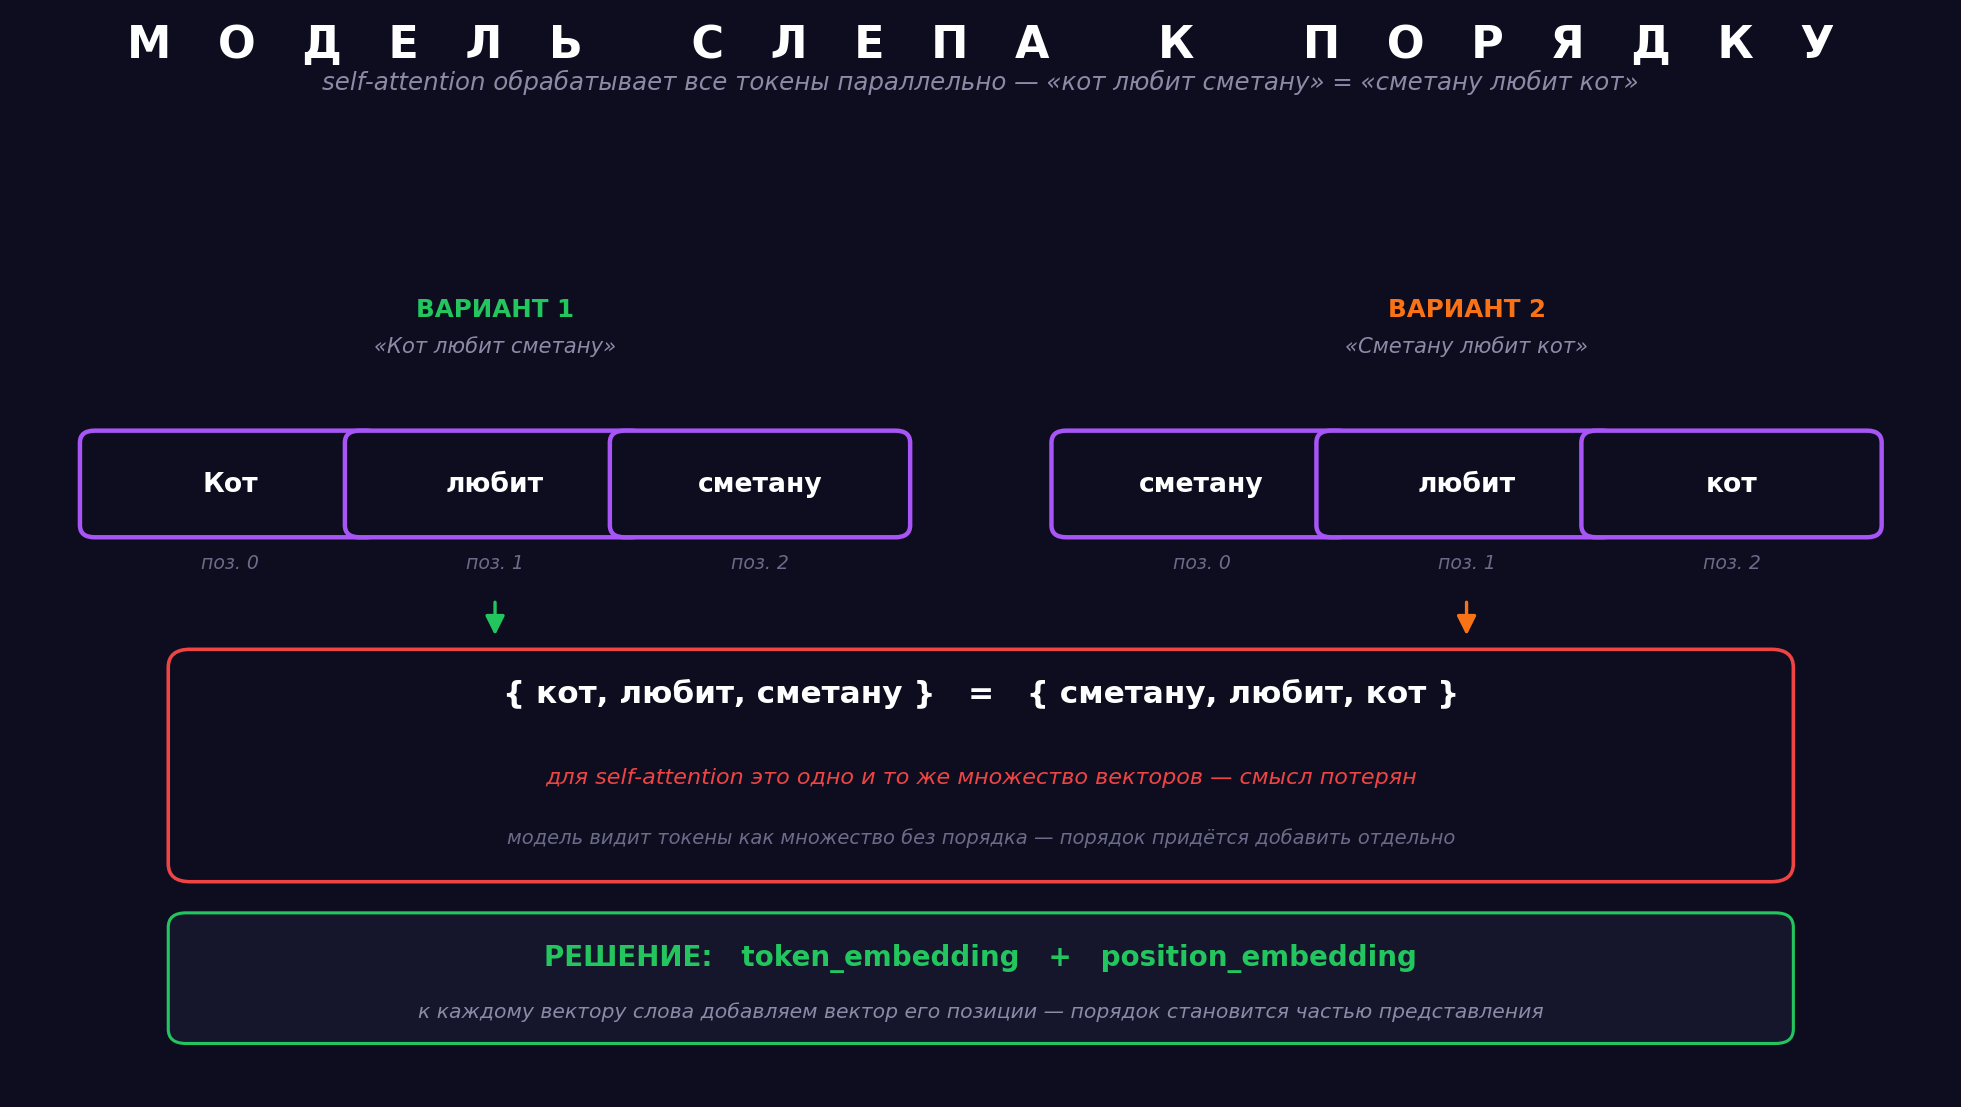

**Решение: Позиционное кодирование**

Нам нужно добавить к вектору слова ещё один вектор, который кодирует его позицию в предложении.

- Вектор слова «Кот» (позиция 0) + Вектор позиции 0
- Вектор слова «любит» (позиция 1) + Вектор позиции 1
- Вектор слова «сметану» (позиция 2) + Вектор позиции 2

Мы просто складываем эти векторы поэлементно.

`Final Vector = Token Embedding + Position Embedding`

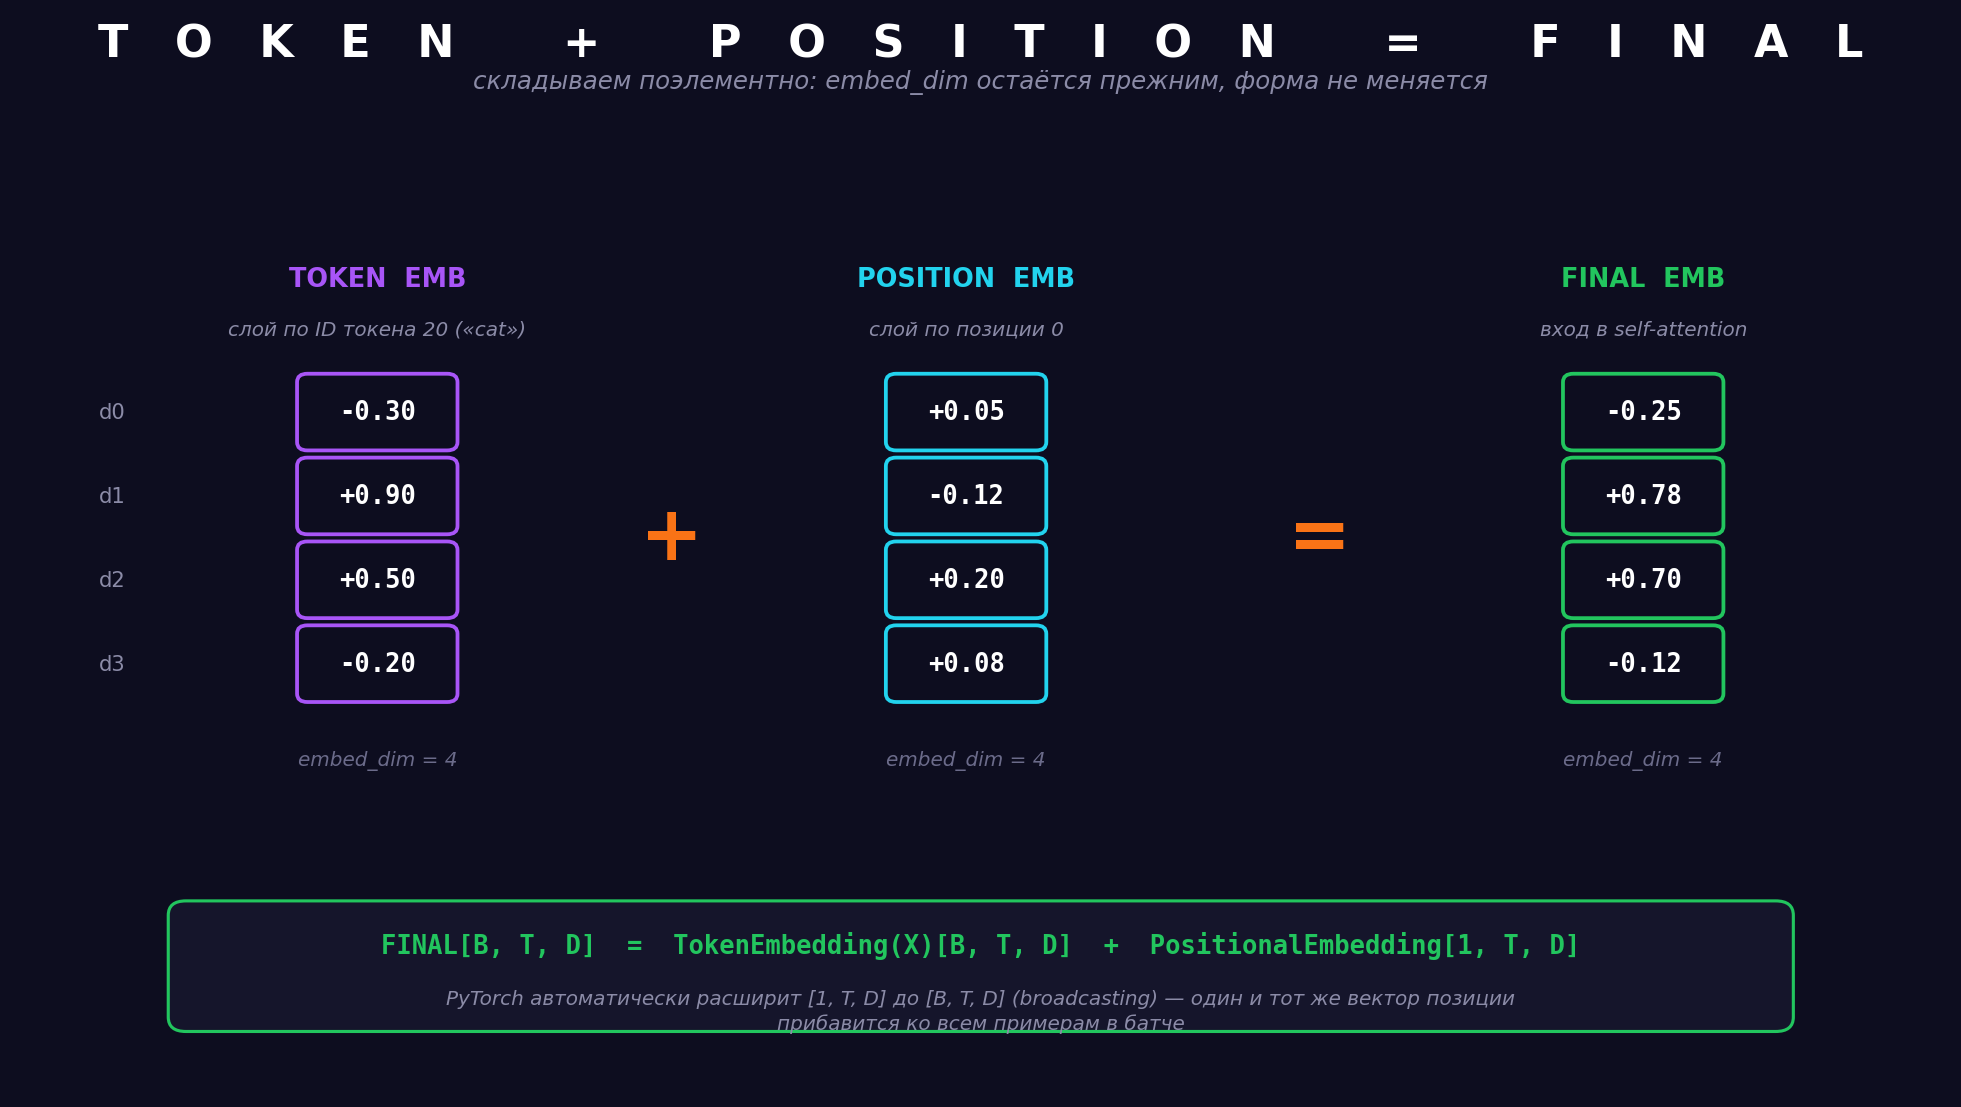

Существует два основных способа создать векторы позиций:

1. Обучаемые (Learned): Просто ещё одна таблица, где строка — это номер позиции (0, 1, 2...), а значения учатся вместе с моделью. (Используется в GPT, BERT).
2. Фиксированные (Sinusoidal): Вычисляются по формуле синусов и косинусов разной частоты. (Использовалось в оригинальной статье "Attention is All You Need").

Для нашего проекта, ориентированного на архитектуру типа GPT, мы реализуем обучаемые позиционные эмбеддинги- так делалось в GPT-2 и BERT. 

Давайте создадим новый файл в нашем проекте. Мы соблюдаем структуру, поэтому не пишем всё в main.py.

`embedding.py`

**Разбор кода**

1. TokenEmbedding: Это обёртка над стандартным nn.Embedding из PyTorch. Она принимает vocab_size (размер словаря токенизатора) и embed_dim.

2. PositionalEmbedding: Здесь мы создаём ещё одну таблицу эмбеддингов, но её размер зависит от максимальной длины предложения (max_length). В методе forward мы генерируем последовательность чисел 0, 1, 2... и превращаем их в векторы.
3. EmbeddingLayer: Это фасад. Пользователь (наша будущая модель) просто передаёт IDs токенов, а внутри происходит магия: lookup токена, lookup позиции, сложение. 
4. _init_weights: Нейросети чувствительны к начальным значениям весов. Мы инициализируем их нормальным распределением с маленьким стандартным отклонением (0.02), что является стандартом для трансформеров.

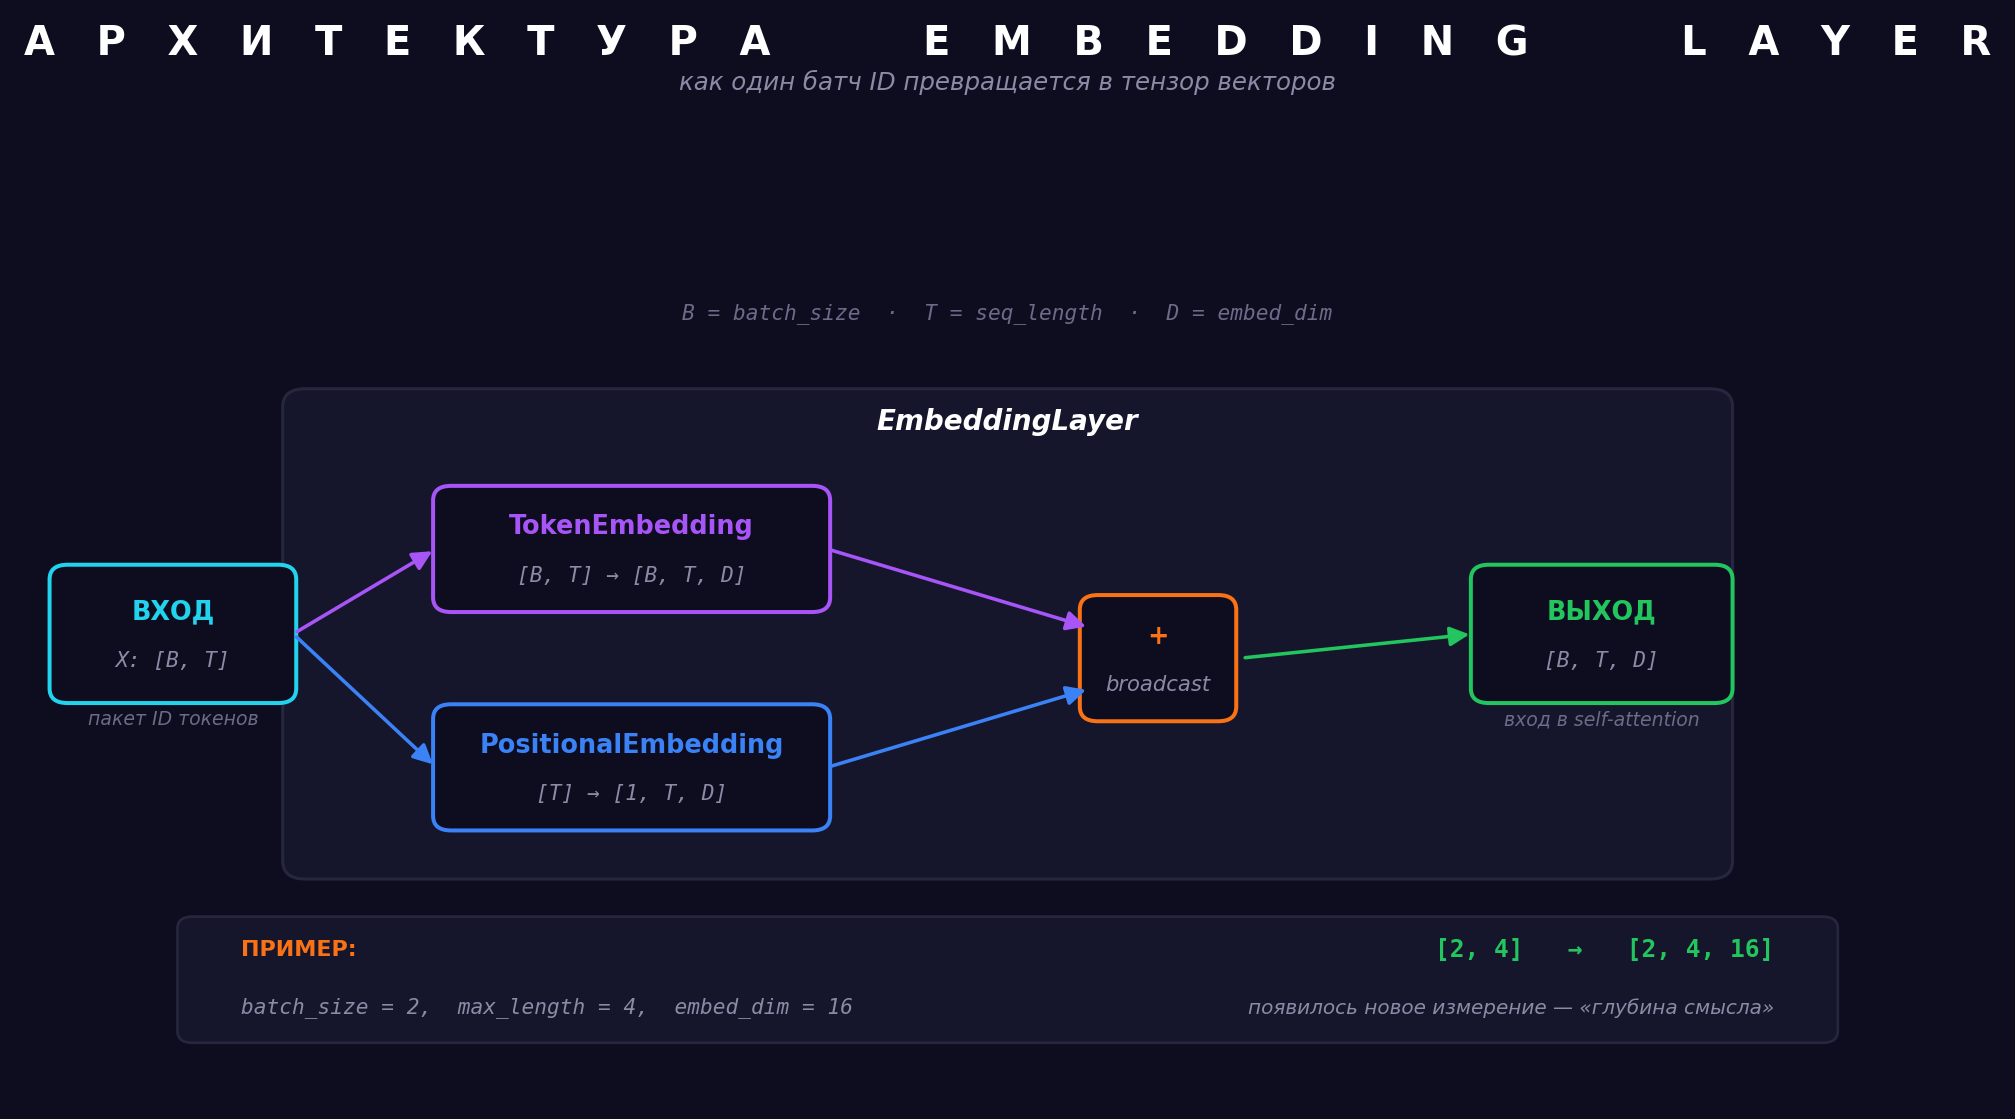

Чтобы новый код заработал, нам нужно добавить параметр размерности в конфигурацию и проверить работу слоя в главном файле. Поэтому обновим файлы.

Что здесь важно заметить:

- Изменение размерности: На вход пришло [2, 4] (числа), вышло [2, 4, 16] (векторы). Появилось третье измерение — глубина смысла. 
- grad_fn: Обратите внимание на `grad_fn=<SliceBackward0>`. Это значит, что операция записана в граф вычислений. Когда мы позже будем вычислять ошибку обучения, PyTorch сможет понять, как изменить веса в таблице эмбеддингов, чтобы уменьшить ошибку. Без этого обучение невозможно.

**Почему мы складываем, а не конкатенируем?**

Вы могли спросить: «Почему бы не приписать вектор позиции к вектору токена? Получился бы вектор длиной 32 (16+16)».

Мы складываем их по двум причинам:

- **Экономия параметров:** Если мы конкатенируем, размерность растёт, и следующие слои сети должны стать шире, чтобы обработать это. Сложение сохраняет размерность embed_dim.
- **Семантика:** Позиция — это модификатор смысла. Слово «Кот» (субъект) в начале предложения и слово «кот» (объект) в конце — это одно и то же понятие, но с разной ролью. Сложение позволяет «подсветить» роль позиции, не создавая совершенно новое понятие.

Давайте зафиксируем полный путь данных от сырого текста до входа в нейросеть. Этот процесс состоит из следующих этапов:

1. Токенизация: Исходный текст разбивается на токены (слова, части слов или символы) и преобразуется в последовательность числовых идентификаторов (ID) с помощью словаря токенизатора.
2. Нарезка на примеры: Длинная последовательность ID разбивается методом скользящего окна на пары «Вход (X)» и «Цель (Y)». Вход используется для предсказания, а Цель — для проверки ответа модели.
3. Пакетирование (Batching): Отдельные примеры группируются в пакеты. Это позволяет нейросети обрабатывать несколько последовательностей одновременно, используя мощь GPU.
4. Векторизация (Embedding):
    - ID токенов входа (X) преобразуются в плотные векторы через слой Token Embedding.
    - К ним добавляются векторы Positional Embedding, кодирующие порядок слов.
    - В результате формируется входной тензор размерности [Batch, Sequence_Length, Embedding_Dim].
5. Подготовка к обучению: Входной тензор передаётся в основные слои модели. Целевые данные (Y) остаются в виде ID и используются позже для вычисления ошибки (Loss) на выходе модели
